import 

In [ ]:
#! pip install mediapipe==0.10.21 opencv-contrib-python numpy scipy matplotlib pandas -q

import cv2, mediapipe as mp, numpy as np, math, os, re, time
import pandas as pd, matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from pathlib import Path

from IPython.display import display

print(f'OpenCV {cv2.__version__} | MediaPipe {mp.__version__} | NumPy {np.__version__} | Pandas {pd.__version__}')
print('All imports OK')

OpenCV 4.11.0 | MediaPipe 0.10.9 | NumPy 1.26.4 | Pandas 2.3.3
All imports OK



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\sunil\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


Configuration

In [ ]:

FOLDER_A = r'C:\Users\sunil\Downloads\videos-20260602T083739Z-3-001'
FOLDER_B = r'C:\Users\sunil\Downloads\videos-20260602T083729Z-3-001'

OUTPUT_DIR = r'C:\Users\sunil\Downloads\keraal_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

MODEL_COMPLEXITY  = 1     
MIN_DETECT_CONF   = 0.3   
MIN_TRACK_CONF    = 0.3
VISIBILITY_THRESH = 0.4

UPSCALE_W = 1440          
UPSCALE_H = 1080          
CROP_X    = (0.20, 0.80)  
CROP_Y    = (0.05, 0.95)  

CLAHE_CLIP       = 4.0    
CLAHE_GRID       = (8, 8)
SAVGOL_WINDOW    = 7      
SAVGOL_ORDER     = 3
MAX_INTERP_GAP   = 5      
VEL_SPIKE_THRESH = 300    

ANAT_LIMITS = {
    'angle_knee_L': (0, 175),  'angle_knee_R': (0, 175),
    'angle_hip_L':  (-30, 140),'angle_hip_R':  (-30, 140),
    'angle_ankle_L':(50, 140), 'angle_ankle_R':(50, 140),
}

SAVE_VIDEO = False  

print(f'Output: {OUTPUT_DIR}')
print('Configuration set')

Output: C:\Users\sunil\Downloads\keraal_output
Configuration set



Maps MediaPipe landmark indices → KERAAL/Kinect canonical joint names.

| Canonical | MediaPipe idx | Notes |
|---|---|---|
| SpineBase | avg(23,24) | Pelvis centre — **root joint for centering** |
| SpineMid  | avg(11,12) | Upper spine estimate |
| HipLeft / HipRight | 23 / 24 | |
| KneeLeft / KneeRight | 25 / 26 | |
| AnkleLeft / AnkleRight | 27 / 28 | |
| FootLeft / FootRight | 31 / 32 | |
| ShoulderLeft / ShoulderRight | 11 / 12 | |

In [3]:
CANONICAL_JOINTS = {
    'HipLeft':23, 'HipRight':24, 'KneeLeft':25, 'KneeRight':26,
    'AnkleLeft':27, 'AnkleRight':28, 'FootLeft':31, 'FootRight':32,
    'ShoulderLeft':11, 'ShoulderRight':12,
}
MIDPOINT_JOINTS = {
    'SpineBase': ('HipLeft', 'HipRight'),
    'SpineMid':  ('ShoulderLeft', 'ShoulderRight'),
}
ALL_JOINTS = list(CANONICAL_JOINTS) + list(MIDPOINT_JOINTS)
JOINT_COLS = [f'{j}_{ax}' for j in ALL_JOINTS for ax in ('x', 'y', 'z')]
BASE_COLS  = ['subject_id', 'session', 'label', 'frame_id', 'time_s', 'detection']

SESSION_LABEL = {'1': 'novice', '2': 'professional'}
_KERAAL_RE    = re.compile(r'G2A-Anon-CTK-S(\d+)-Roscoff-(\d+)', re.IGNORECASE)

print(f'{len(ALL_JOINTS)} canonical joints  |  {len(JOINT_COLS)} coordinate columns per frame')
print('Joints:', ALL_JOINTS)

12 canonical joints  |  36 coordinate columns per frame
Joints: ['HipLeft', 'HipRight', 'KneeLeft', 'KneeRight', 'AnkleLeft', 'AnkleRight', 'FootLeft', 'FootRight', 'ShoulderLeft', 'ShoulderRight', 'SpineBase', 'SpineMid']


Helper

In [ ]:
_clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_GRID)

def enhance(frame):
    l, a, b = cv2.split(cv2.cvtColor(frame, cv2.COLOR_BGR2LAB))
    return cv2.cvtColor(cv2.merge([_clahe.apply(l), a, b]), cv2.COLOR_LAB2BGR)

def prepare_frame(frame):
    big = cv2.resize(frame, (UPSCALE_W, UPSCALE_H), interpolation=cv2.INTER_LINEAR)
    h, w = big.shape[:2]
    x1, y1 = int(w * CROP_X[0]), int(h * CROP_Y[0])
    x2, y2 = int(w * CROP_X[1]), int(h * CROP_Y[1])
    return enhance(big[y1:y2, x1:x2])

def get_xyz(lm, idx):
    p = lm[idx]
    return (p.x, p.y, p.z) if p.visibility >= VISIBILITY_THRESH else None

def extract_canonical_row(lm):
    coords = {j: get_xyz(lm, idx) for j, idx in CANONICAL_JOINTS.items()}
    for j, (j1, j2) in MIDPOINT_JOINTS.items():
        a, b = coords.get(j1), coords.get(j2)
        coords[j] = tuple((a[i]+b[i])/2 for i in range(3)) if a and b else None
    row = {}
    for j in ALL_JOINTS:
        xyz = coords[j]
        for i, ax in enumerate(('x','y','z')):
            row[f'{j}_{ax}'] = xyz[i] if xyz else float('nan')
    return row

def mask_spikes(s, fps):
    s = s.copy().astype(float)
    s[s.diff().abs() * fps > VEL_SPIKE_THRESH] = float('nan')
    return s

def interp_gap(s, max_gap=MAX_INTERP_GAP):
    s = s.copy().astype(float); mask = s.isna()
    if not mask.any(): return s
    run_id  = mask.ne(mask.shift()).cumsum()
    run_len = mask.groupby(run_id).transform('sum')
    si = s.interpolate(method='linear', limit_direction='both')
    si[mask & (run_len > max_gap)] = float('nan')
    return si

def clean_nulls(df, excl=('subject_id','session','label')):
    df = df.copy()
    for col in [c for c in df.columns if c not in excl]:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        if df[col].isna().any():
            df[col] = df[col].interpolate(method='linear', limit_direction='both').ffill().bfill().fillna(0)
    return df

print('Helper functions defined')

Helper functions defined


Video 



In [ ]:
def discover_videos(*user_folders):
    search_dirs = list(user_folders) + [
        '/mnt/user-data/uploads',
        '/content',
        str(Path.cwd()),
    ]
    seen, videos = set(), []
    for folder in search_dirs:
        p = Path(folder)
        if not p.exists():
            continue
        for mp4 in sorted(p.rglob('*.mp4')):
            real = str(mp4.resolve())
            if real in seen:
                continue
            seen.add(real)
            m = _KERAAL_RE.search(mp4.stem)
            if not m:
                continue
            sess, subj = m.group(1), m.group(2)
            videos.append({
                'subject_id': subj,
                'session':    sess,
                'label':      SESSION_LABEL.get(sess, f'session_{sess}'),
                'filepath':   str(mp4),
            })

    print(f'Discovered {len(videos)} KERAAL videos:')
    for v in videos:
        print(f"  Subject {v['subject_id']:>3s}  S{v['session']}  "
              f"{v['label']:<14}  {Path(v['filepath']).name}")
    if len(videos) == 0:
        print('  [!] No videos found. Check FOLDER_A / FOLDER_B paths in Cell 2.')
    return videos


videos = discover_videos(FOLDER_A, FOLDER_B)

Discovered 19 KERAAL videos:
  Subject 009  S1  novice          G2A-Anon-CTK-S1-Roscoff-009.mp4
  Subject 012  S1  novice          G2A-Anon-CTK-S1-Roscoff-012.mp4
  Subject 013  S1  novice          G2A-Anon-CTK-S1-Roscoff-013.mp4
  Subject 043  S1  novice          G2A-Anon-CTK-S1-Roscoff-043.mp4
  Subject 051  S1  novice          G2A-Anon-CTK-S1-Roscoff-051.mp4
  Subject 059  S1  novice          G2A-Anon-CTK-S1-Roscoff-059.mp4
  Subject 003  S2  professional    G2A-Anon-CTK-S2-Roscoff-003.mp4
  Subject 018  S2  professional    G2A-Anon-CTK-S2-Roscoff-018.mp4
  Subject 021  S2  professional    G2A-Anon-CTK-S2-Roscoff-021.mp4
  Subject 025  S2  professional    G2A-Anon-CTK-S2-Roscoff-025.mp4
  Subject 077  S3  session_3       G2A-Anon-CTK-S3-Roscoff-077.mp4
  Subject 091  S3  session_3       G2A-Anon-CTK-S3-Roscoff-091.mp4
  Subject 001  S4  session_4       G2A-Anon-CTK-S4-Roscoff-001.mp4
  Subject 015  S4  session_4       G2A-Anon-CTK-S4-Roscoff-015.mp4
  Subject 026  S4  session_4     

Preprocessing

In [ ]:
def root_center(df):
    df = df.copy()
    for j in ALL_JOINTS:
        for ax in ('x', 'y', 'z'):
            df[f'{j}_{ax}'] -= df[f'SpineBase_{ax}']
    return df

def _bone_len(df, j1, j2):
    return np.sqrt(sum((df[f'{j1}_{ax}'] - df[f'{j2}_{ax}'])**2 for ax in 'xyz'))

def bone_normalize(df):
    df = df.copy()
    det = df['detection'] == 1
    heights = []
    for hip, knee, ankle in [('HipLeft','KneeLeft','AnkleLeft'),
                              ('HipRight','KneeRight','AnkleRight')]:
        h = (_bone_len(df,hip,knee) + _bone_len(df,knee,ankle) +
             _bone_len(df,'SpineBase','SpineMid'))[det].median()
        if not np.isnan(h): heights.append(h)
    body_h = np.mean(heights) if heights else 1.0
    df['body_height_est'] = round(float(body_h), 6)
    df[JOINT_COLS] = df[JOINT_COLS] / max(body_h, 1e-6)
    return df

print('root_center() and bone_normalize() defined')

root_center() and bone_normalize() defined


 Feature Extraction 

In [ ]:
def angle_3d(df, a, b, c):
    A = df[[f'{a}_x',f'{a}_y',f'{a}_z']].values
    B = df[[f'{b}_x',f'{b}_y',f'{b}_z']].values
    C = df[[f'{c}_x',f'{c}_y',f'{c}_z']].values
    ba, bc = A - B, C - B
    n = np.linalg.norm(ba, axis=1) * np.linalg.norm(bc, axis=1)
    dot = np.einsum('ij,ij->i', ba, bc)
    with np.errstate(invalid='ignore', divide='ignore'):
        ang = np.degrees(np.arccos(np.clip(np.where(n > 0, dot/n, 0), -1, 1)))
    ang[n == 0] = np.nan
    return pd.Series(ang, index=df.index)

def extract_features(df):
    df   = df.copy()
    dt   = df['time_s'].diff().median()
    fps  = 1.0 / dt if dt and dt > 0 else 10.0
    _sw  = max(SAVGOL_ORDER + 2, round(SAVGOL_WINDOW / 30.0 * fps))
    sw   = _sw if _sw % 2 == 1 else _sw + 1

    ANGLE_DEFS = [
        ('angle_knee_L',  'HipLeft',   'KneeLeft',   'AnkleLeft'),
        ('angle_knee_R',  'HipRight',  'KneeRight',  'AnkleRight'),
        ('angle_hip_L',   'SpineBase', 'HipLeft',    'KneeLeft'),
        ('angle_hip_R',   'SpineBase', 'HipRight',   'KneeRight'),
        ('angle_ankle_L', 'KneeLeft',  'AnkleLeft',  'FootLeft'),
        ('angle_ankle_R', 'KneeRight', 'AnkleRight', 'FootRight'),
    ]
    ang_cols = [d[0] for d in ANGLE_DEFS]
    for name, a, b, c in ANGLE_DEFS:
        lo, hi = ANAT_LIMITS.get(name, (0, 360))
        df[name] = angle_3d(df, a, b, c).clip(lo, hi)
    for col in ang_cols:
        df[col] = mask_spikes(df[col], fps)
        df[col] = interp_gap(df[col])
    for col in ang_cols:
        s, sc = df[col].dropna(), col + '_smooth'
        if len(s) >= sw:
            sm = pd.Series(np.nan, index=df.index)
            sm[s.index] = savgol_filter(s.values, sw, SAVGOL_ORDER)
            df[sc] = sm
        else:
            df[sc] = df[col]
    for col in ang_cols:
        sc = col + '_smooth'
        df[col + '_vel']  = df[sc].diff() * fps
        df[col + '_acc']  = df[col + '_vel'].diff() * fps
        df[col + '_jerk'] = df[col + '_acc'].diff() * fps

    for jnt, lc, rc in [('knee',  'angle_knee_L_smooth',  'angle_knee_R_smooth'),
                         ('hip',   'angle_hip_L_smooth',   'angle_hip_R_smooth'),
                         ('ankle', 'angle_ankle_L_smooth', 'angle_ankle_R_smooth')]:
        L, R = df[lc], df[rc]
        df[f'symmetry_{jnt}'] = 2 * (L - R) / (L + R).replace(0, np.nan) * 100

    return df

print('extract_features() defined')

extract_features() defined


 Main Extraction Loop

In [ ]:
mpPose = mp.solutions.pose

def process_video(info, pose_model):
    sid, sess, label, vpath = info['subject_id'], info['session'], info['label'], info['filepath']
    cap = cv2.VideoCapture(vpath)
    if not cap.isOpened():
        print(f'[SKIP] Cannot open: {vpath}'); return None

    fps_vid    = cap.get(cv2.CAP_PROP_FPS) or 10.0
    rows       = []
    frame_idx  = 0
    detected   = 0
    t0         = time.time()

    writer = None
    if SAVE_VIDEO:
        out_vid = os.path.join(OUTPUT_DIR, f'S{sess}_{sid}_annotated.mp4')
        h0, w0  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)), int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        writer  = cv2.VideoWriter(out_vid, cv2.VideoWriter_fourcc(*'mp4v'), fps_vid, (w0, h0))

    while True:
        ok, frame = cap.read()
        if not ok: break
        frame_idx += 1
        prepped = prepare_frame(frame)
        rgb     = cv2.cvtColor(prepped, cv2.COLOR_BGR2RGB)
        rgb.flags.writeable = False
        res = pose_model.process(rgb)

        row = {'subject_id': sid, 'session': sess, 'label': label,
               'frame_id': frame_idx, 'time_s': round(frame_idx / fps_vid, 4), 'detection': 0}
        row.update({col: float('nan') for col in JOINT_COLS})

        if res.pose_landmarks:
            detected += 1
            row['detection'] = 1
            row.update(extract_canonical_row(res.pose_landmarks.landmark))
            if SAVE_VIDEO and writer:
                lm = res.pose_landmarks.landmark
                h, w = prepped.shape[:2]
                for si, ei in [(23,25),(25,27),(24,26),(26,28),(23,24)]:
                    ps, pe = lm[si], lm[ei]
                    if ps.visibility >= VISIBILITY_THRESH and pe.visibility >= VISIBILITY_THRESH:
                        cv2.line(prepped, (int(ps.x*w),int(ps.y*h)),
                                          (int(pe.x*w),int(pe.y*h)), (255,165,0), 2, cv2.LINE_AA)
                cv2.putText(prepped, f'S{sess} {label}', (10,28),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0,220,255), 2)

        if writer: writer.write(prepped if SAVE_VIDEO else frame)
        rows.append(row)

    cap.release()
    if writer: writer.release()
    if frame_idx == 0: return None

    df = pd.DataFrame(rows, columns=BASE_COLS + JOINT_COLS)
    print(f'  Subject {sid:>3s}  S{sess}  ({label:<14})  '
          f'{frame_idx} frames  det={100*detected/frame_idx:.0f}%  {time.time()-t0:.1f}s')
    return df

all_dfs = []
print(f'Processing {len(videos)} videos...\n')

with mpPose.Pose(
    static_image_mode        = False,
    model_complexity         = MODEL_COMPLEXITY,
    smooth_landmarks         = True,
    min_detection_confidence = MIN_DETECT_CONF,
    min_tracking_confidence  = MIN_TRACK_CONF,
) as pose:
    for i, v in enumerate(videos, 1):
        print(f'[{i:>3}/{len(videos)}]', end=' ')
        df = process_video(v, pose)
        if df is not None:
            all_dfs.append(df)

print(f'\nExtracted {len(all_dfs)}/{len(videos)} videos')

Processing 19 videos...

[  1/19]   Subject 009  S1  (novice        )  360 frames  det=98%  32.1s
[  2/19]   Subject 012  S1  (novice        )  357 frames  det=96%  31.5s
[  3/19]   Subject 013  S1  (novice        )  364 frames  det=97%  30.7s
[  4/19]   Subject 043  S1  (novice        )  381 frames  det=99%  31.7s
[  5/19]   Subject 051  S1  (novice        )  349 frames  det=100%  30.9s
[  6/19]   Subject 059  S1  (novice        )  367 frames  det=98%  32.9s
[  7/19]   Subject 003  S2  (professional  )  438 frames  det=100%  38.9s
[  8/19]   Subject 018  S2  (professional  )  383 frames  det=100%  34.3s
[  9/19]   Subject 021  S2  (professional  )  371 frames  det=100%  35.3s
[ 10/19]   Subject 025  S2  (professional  )  404 frames  det=100%  39.3s
[ 11/19]   Subject 077  S3  (session_3     )  384 frames  det=100%  38.6s
[ 12/19]   Subject 091  S3  (session_3     )  361 frames  det=100%  36.5s
[ 13/19]   Subject 001  S4  (session_4     )  358 frames  det=100%  36.0s
[ 14/19]   Subject

Preprocess All Extracted DataFrames

In [ ]:
processed = []

for df in all_dfs:
    sid   = df['subject_id'].iloc[0]
    sess  = df['session'].iloc[0]
    label = df['label'].iloc[0]

    pdf = df.pipe(root_center)        
    pdf = pdf.pipe(bone_normalize)    
    pdf = pdf.pipe(extract_features)  
    pdf = pdf.pipe(clean_nulls)       

    processed.append(pdf)

    out = os.path.join(OUTPUT_DIR, f'S{sess}_{sid}_{label}_processed.csv')
    pdf.to_csv(out, index=False)

    feat_cols = [c for c in pdf.columns if any(x in c for x in
                 ['angle_','_vel','_acc','_jerk','symmetry'])]
    print(f'  Subject {sid}  S{sess}  ({label})  '
          f'{len(pdf)} frames  {len(feat_cols)} feature cols  → {Path(out).name}')

print(f'\n{len(processed)} videos preprocessed')

  Subject 009  S1  (novice)  360 frames  33 feature cols  → S1_009_novice_processed.csv
  Subject 012  S1  (novice)  357 frames  33 feature cols  → S1_012_novice_processed.csv
  Subject 013  S1  (novice)  364 frames  33 feature cols  → S1_013_novice_processed.csv
  Subject 043  S1  (novice)  381 frames  33 feature cols  → S1_043_novice_processed.csv
  Subject 051  S1  (novice)  349 frames  33 feature cols  → S1_051_novice_processed.csv
  Subject 059  S1  (novice)  367 frames  33 feature cols  → S1_059_novice_processed.csv
  Subject 003  S2  (professional)  438 frames  33 feature cols  → S2_003_professional_processed.csv
  Subject 018  S2  (professional)  383 frames  33 feature cols  → S2_018_professional_processed.csv
  Subject 021  S2  (professional)  371 frames  33 feature cols  → S2_021_professional_processed.csv
  Subject 025  S2  (professional)  404 frames  33 feature cols  → S2_025_professional_processed.csv
  Subject 077  S3  (session_3)  384 frames  33 feature cols  → S3_077_se

 Split Correct / Incorrect

In [10]:
master = pd.concat(processed, ignore_index=True)
master.to_csv(os.path.join(OUTPUT_DIR, 'KERAAL_ALL_processed.csv'), index=False)

correct_df   = master[master['label'] == 'professional']
incorrect_df = master[master['label'] == 'novice']

correct_df.to_csv(  os.path.join(OUTPUT_DIR, 'KERAAL_correct_professional.csv'),   index=False)
incorrect_df.to_csv(os.path.join(OUTPUT_DIR, 'KERAAL_incorrect_novice.csv'), index=False)

print(f'Master: {len(master):,} rows × {len(master.columns)} cols  |  '
      f'Nulls: {int(master.isna().sum().sum())}')
print(f'\nCorrect   (professional S2): {len(correct_df):,} frames  '
      f'({correct_df["subject_id"].nunique()} subjects)')
print(f'Incorrect (novice S1):       {len(incorrect_df):,} frames  '
      f'({incorrect_df["subject_id"].nunique()} subjects)')

print('\nBreakdown:')
display(master.groupby(['label','session'])['frame_id'].agg(['count'])
        .rename(columns={'count':'frames'}).reset_index())

Master: 7,244 rows × 76 cols  |  Nulls: 0

Correct   (professional S2): 1,596 frames  (4 subjects)
Incorrect (novice S1):       2,178 frames  (6 subjects)

Breakdown:


,label,session,frames
0,novice,1,2178
1,professional,2,1596
2,session_3,3,745
3,session_4,4,2725


ROM Summary

In [11]:
SMOOTH_ANGLE_COLS = [
    'angle_knee_L_smooth','angle_knee_R_smooth',
    'angle_hip_L_smooth', 'angle_hip_R_smooth',
    'angle_ankle_L_smooth','angle_ankle_R_smooth',
]

rom_rows = []
for df in processed:
    sid, sess, label = df['subject_id'].iloc[0], df['session'].iloc[0], df['label'].iloc[0]
    det_rate = df['detection'].mean()
    det_flag = 'ok' if det_rate >= 0.5 else 'low' if det_rate >= 0.3 else 'poor'
    r = {'subject_id':sid,'session':sess,'label':label,
         'det_%':f'{100*det_rate:.1f}','det_flag':det_flag,'frames':len(df)}
    for col in SMOOTH_ANGLE_COLS:
        s     = df[col].dropna()
        short = col.replace('_smooth','').replace('angle_','')
        r[f'{short}_mean'] = f'{s.mean():.1f}' if len(s) else 'N/A'
        r[f'{short}_ROM']  = f'{s.max()-s.min():.1f}' if len(s) else 'N/A'
        r[f'{short}_std']  = f'{s.std():.1f}' if len(s) else 'N/A'
    rom_rows.append(r)

rom_summary = pd.DataFrame(rom_rows)
rom_summary.to_csv(os.path.join(OUTPUT_DIR, 'KERAAL_ROM_summary.csv'), index=False)
print('ROM Summary:')
display(rom_summary)

ROM Summary:


,subject_id,session,label,det_%,det_flag,frames,knee_L_mean,knee_L_ROM,knee_L_std,knee_R_mean,...,hip_L_std,hip_R_mean,hip_R_ROM,hip_R_std,ankle_L_mean,ankle_L_ROM,ankle_L_std,ankle_R_mean,ankle_R_ROM,ankle_R_std
0,009,1,novice,98.1,ok,360,77.8,142.7,34.5,93.1,...,19.9,98.7,80.9,13.4,65.6,98.9,26.2,62.8,102.5,26.9
1,012,1,novice,95.8,ok,357,89.7,154.0,34.0,106.4,...,20.7,103.8,108.2,14.2,70.2,96.5,28.5,69.0,103.7,30.1
2,013,1,novice,97.0,ok,364,74.3,147.1,28.9,83.8,...,21.2,107.1,76.0,16.2,62.3,97.2,23.8,60.7,97.7,24.3
3,043,1,novice,99.2,ok,381,82.5,127.0,27.9,92.0,...,16.3,98.3,67.1,13.3,62.0,92.6,17.8,57.3,87.4,14.9
4,051,1,novice,100.0,ok,349,85.3,122.2,22.3,108.9,...,20.3,102.3,97.0,11.1,62.8,94.2,15.8,58.8,94.6,16.3
5,059,1,novice,98.1,ok,367,76.4,144.4,22.6,93.2,...,17.9,96.4,82.5,11.4,59.5,97.2,13.4,57.4,95.1,13.8
6,003,2,professional,100.0,ok,438,105.9,147.7,15.4,115.6,...,10.7,93.1,98.7,13.8,53.2,81.0,8.9,53.9,68.5,9.0
7,018,2,professional,100.0,ok,383,100.4,90.4,13.0,112.2,...,12.1,93.4,75.4,15.4,50.5,21.6,2.1,50.6,23.1,2.5
8,021,2,professional,100.0,ok,371,103.7,103.0,14.6,110.0,...,10.9,87.3,73.6,14.5,53.2,72.0,9.6,53.9,55.2,9.6
9,025,2,professional,100.0,ok,404,97.3,105.3,20.5,109.0,...,19.6,91.2,69.0,15.2,64.1,94.9,30.4,63.2,93.9,28.2


Angle Time-Series

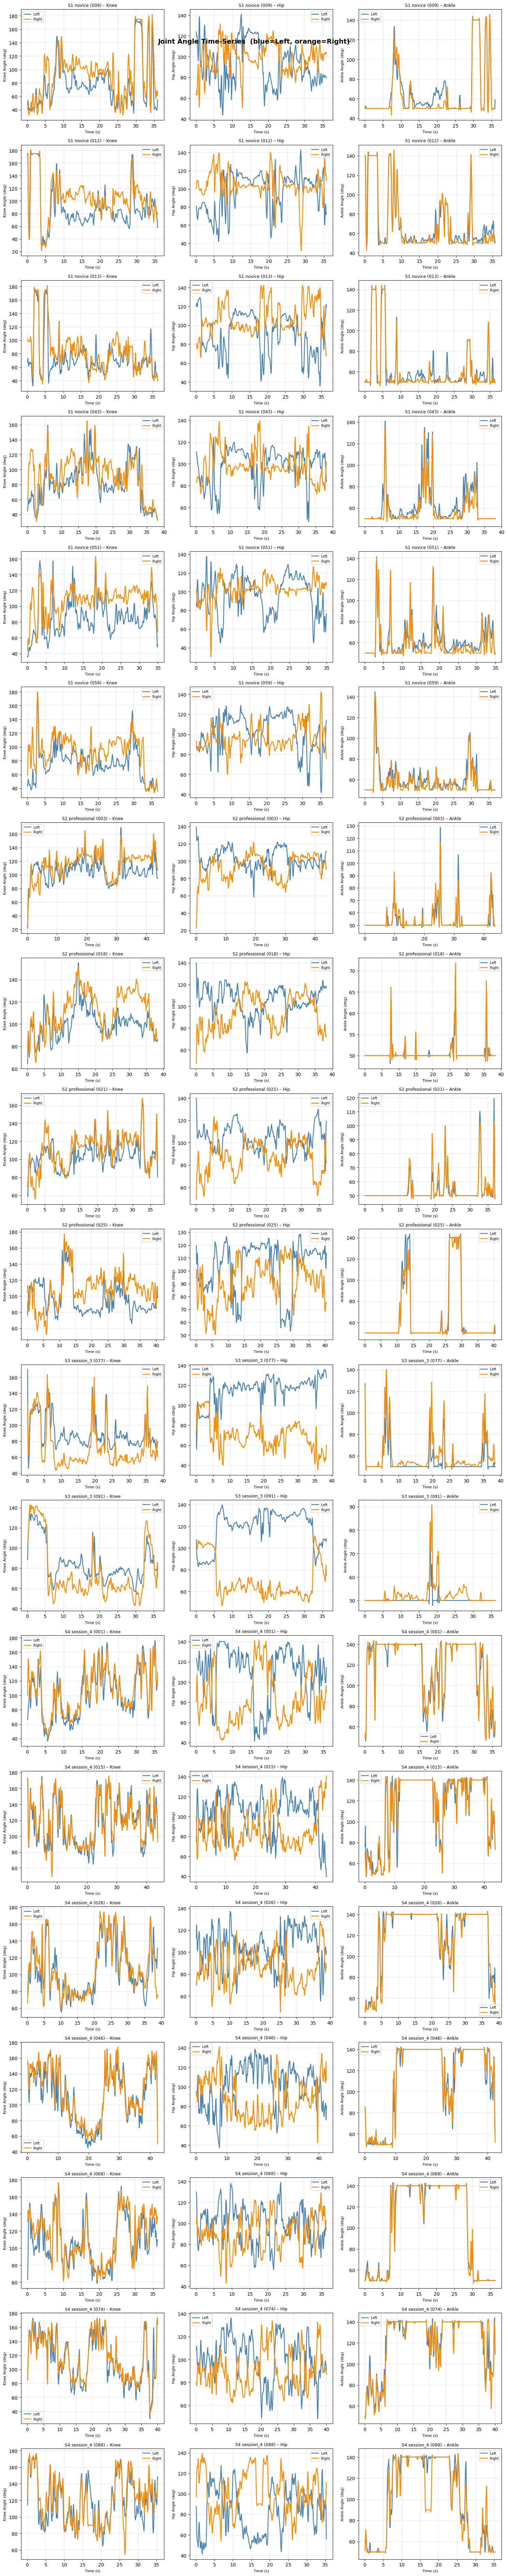

Saved: C:\Users\sunil\Downloads\keraal_output\angle_timeseries.png


In [12]:
PLOT_PAIRS = [
    ('angle_knee_L_smooth',  'angle_knee_R_smooth',  'Knee Angle (deg)'),
    ('angle_hip_L_smooth',   'angle_hip_R_smooth',   'Hip Angle (deg)'),
    ('angle_ankle_L_smooth', 'angle_ankle_R_smooth', 'Ankle Angle (deg)'),
]

fig, axes = plt.subplots(len(processed), 3, figsize=(15, 4*len(processed)), squeeze=False)
fig.suptitle('Joint Angle Time-Series  (blue=Left, orange=Right)', fontsize=14, fontweight='bold')

for ri, df in enumerate(processed):
    sid   = df['subject_id'].iloc[0]
    label = df['label'].iloc[0]
    t     = df['time_s']
    for ci, (lc, rc, ylabel) in enumerate(PLOT_PAIRS):
        ax = axes[ri][ci]
        ax.plot(t, df[lc], color='steelblue',  lw=1.8, label='Left')
        ax.plot(t, df[rc], color='darkorange', lw=1.8, label='Right')
        ax.set_title(f'S{df["session"].iloc[0]} {label} ({sid}) – {ylabel.split()[0]}', fontsize=9)
        ax.set_xlabel('Time (s)', fontsize=8)
        ax.set_ylabel(ylabel, fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
p = os.path.join(OUTPUT_DIR, 'angle_timeseries.png')
plt.savefig(p, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

Plot: ROM Novice vs Professional

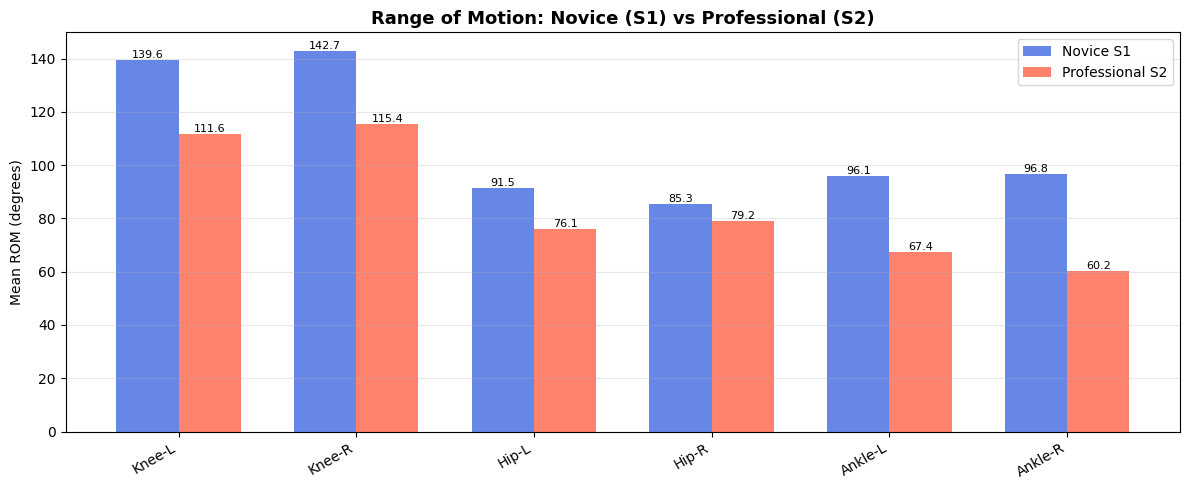

Saved: C:\Users\sunil\Downloads\keraal_output\ROM_comparison.png


In [13]:
rom_num = rom_summary.copy()
rom_cols = [c for c in rom_num.columns if c.endswith('_ROM')]
for col in rom_cols:
    rom_num[col] = pd.to_numeric(rom_num[col], errors='coerce')

nov_rom = rom_num[rom_num['label']=='novice'][rom_cols].mean()
pro_rom = rom_num[rom_num['label']=='professional'][rom_cols].mean()

x = np.arange(len(rom_cols)); w = 0.35
labels_short = [c.replace('_ROM','').replace('knee_','Knee-').replace('hip_','Hip-').replace('ankle_','Ankle-') for c in rom_cols]

fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - w/2, nov_rom.values, w, label='Novice S1',       color='royalblue', alpha=0.8)
b2 = ax.bar(x + w/2, pro_rom.values, w, label='Professional S2', color='tomato',    alpha=0.8)
ax.bar_label(b1, fmt='%.1f', fontsize=8)
ax.bar_label(b2, fmt='%.1f', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels_short, rotation=30, ha='right')
ax.set_ylabel('Mean ROM (degrees)')
ax.set_title('Range of Motion: Novice (S1) vs Professional (S2)', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
p = os.path.join(OUTPUT_DIR, 'ROM_comparison.png')
plt.savefig(p, dpi=130, bbox_inches='tight')
plt.show(); print(f'Saved: {p}')

 Plot: Symmetry Index

Mean Symmetry Index (0 = perfect bilateral symmetry):


,symmetry_knee,symmetry_hip,symmetry_ankle
label,,,
novice,-17.29,-6.41,4.70
professional,-8.84,12.80,-0.46
session_3,19.88,50.43,-5.90
session_4,-3.21,10.71,0.29


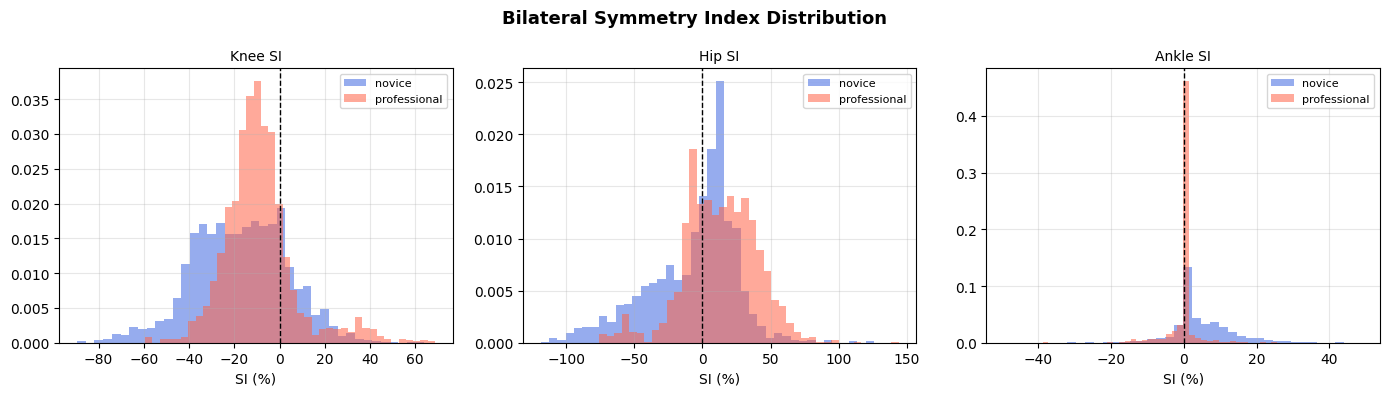

Saved: C:\Users\sunil\Downloads\keraal_output\symmetry_distribution.png


In [14]:
sym_cols = ['symmetry_knee', 'symmetry_hip', 'symmetry_ankle']

print('Mean Symmetry Index (0 = perfect bilateral symmetry):')
display(master.groupby('label')[sym_cols].mean().round(2))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, sym_cols):
    for label, color in [('novice','royalblue'), ('professional','tomato')]:
        s = master[master['label']==label][col].dropna()
        ax.hist(s, bins=40, alpha=0.55, color=color, label=label, density=True)
    ax.axvline(0, color='black', lw=1, ls='--')
    ax.set_title(col.replace('symmetry_','').title() + ' SI', fontsize=10)
    ax.set_xlabel('SI (%)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.suptitle('Bilateral Symmetry Index Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
p = os.path.join(OUTPUT_DIR, 'symmetry_distribution.png')
plt.savefig(p, dpi=130, bbox_inches='tight')
plt.show(); print(f'Saved: {p}')

Summary & Output Manifest

In [15]:
feat_cols = [c for c in master.columns if any(x in c for x in
             ['angle_','_vel','_acc','_jerk','symmetry','body_height'])]

print('=' * 65)
print('KERAAL PIPELINE COMPLETE')
print('=' * 65)
print(f'Total frames:            {len(master):,}')
print(f'Subjects:                {master["subject_id"].nunique()}')
print(f'Correct  (professional): {len(correct_df):,} frames')
print(f'Incorrect (novice):      {len(incorrect_df):,} frames')
print(f'Columns per frame:       {len(master.columns)} '
      f'({len(JOINT_COLS)} coords + {len(feat_cols)} features + {len(BASE_COLS)} base)')
print(f'Null values:             {int(master.isna().sum().sum())}')
print()
print('Output CSVs:')
for f in sorted(Path(OUTPUT_DIR).glob('*.csv')):
    print(f'  {f.name:<48s} {f.stat().st_size/1024:.0f} KB')
print()
print('Ready for Transformer-LSTM pipeline.')
print('  Label encoding:  0 = novice (incorrect)  |  1 = professional (correct)')
print('  Expected shape:  (num_reps, window_len, n_features)')

KERAAL PIPELINE COMPLETE
Total frames:            7,244
Subjects:                19
Correct  (professional): 1,596 frames
Incorrect (novice):      2,178 frames
Columns per frame:       76 (36 coords + 34 features + 6 base)
Null values:             0

Output CSVs:
  KERAAL_ALL_processed.csv                         9070 KB
  KERAAL_correct_professional.csv                  1960 KB
  KERAAL_incorrect_novice.csv                      2772 KB
  KERAAL_ROM_summary.csv                           3 KB
  S1_009_novice_processed.csv                      451 KB
  S1_012_novice_processed.csv                      456 KB
  S1_013_novice_processed.csv                      464 KB
  S1_043_novice_processed.csv                      484 KB
  S1_051_novice_processed.csv                      451 KB
  S1_059_novice_processed.csv                      471 KB
  S2_003_professional_processed.csv                544 KB
  S2_018_professional_processed.csv                466 KB
  S2_021_professional_processed.csv    